In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
df = sns.load_dataset('titanic')


In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [14]:
df.isnull().sum() / len(df) * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [12]:
df["age"].median()

np.float64(28.0)

In [13]:
df["age"] = df["age"].fillna(df["age"].median())

In [20]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode())

In [23]:
df.isnull().sum() / len(df) * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [22]:
df[["age","fare"]].describe()

,age,fare
count,891.000000,891.000000
mean,29.361582,32.204208
std,13.019697,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


<Axes: ylabel='fare'>

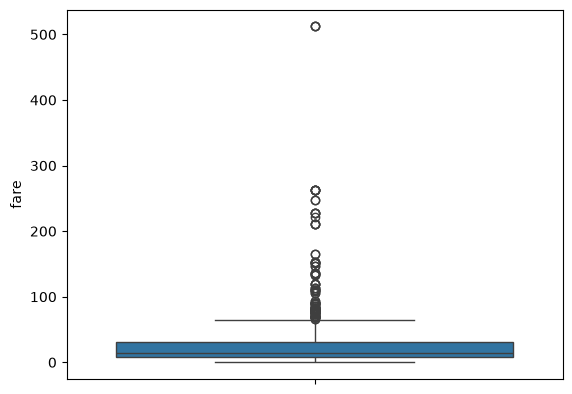

In [27]:
sns.boxplot(df["fare"])

In [31]:
print("Fare mean: ", df["fare"].mean())
print("Fare median: ", df["fare"].median())

Fare mean:  32.204207968574636
Fare median:  14.4542


In [36]:
q1 = df["fare"].quantile(0.25)
q3 = df["fare"].quantile(0.75)

print(f"Q1: {q1}\nQ3: {q3}")

Q1: 7.9104
Q3: 31.0


In [39]:
IQR = q3-q1
lower_fence = q1 - 1.5*IQR
upper_fence = q3 + 1.5*IQR
print(f"fence:  {lower_fence} to {upper_fence}")
# print(f"Lower Fence: {lower_fence}\nUpper Fence: {upper_fence}")

fence:  -26.724 to 65.6344


# SCENARIO 1 #
### Remove Outliers


In [52]:
outliers = df[(df["fare"] < lower_fence) | (df["fare"] > upper_fence)]
outliers.shape

(116, 15)

In [53]:
print("Outliers Found: ", len(outliers))

Outliers Found:  116


In [54]:
clean = df[df["fare"] <= upper_fence]
clean

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,28.0,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [59]:
print( f"Mean: {clean["fare"].mean()}\nMedian : {clean["fare"].median()}")

Mean: 17.82209070967742
Median : 13.0


In [60]:
print("Rows Kept: ", len(clean) , "Dropped rows: ", len(df) - len(clean))

Rows Kept:  775 Dropped rows:  116


# Scenario 2 : Cap The Outliers
### Pull extreme values back to the fence
### keeps every row 

In [63]:
df["fare_capped"] = df["fare"].clip(lower=lower_fence, upper=upper_fence)
df["fare_capped"].max()

np.float64(65.6344)

In [64]:
df["fare_capped"].shape[0]

891

In [67]:
print(f"Mean before capping: {round(df["fare"].mean(),2)} & Mean after capping: {round(df["fare_capped"].mean(),2)}")
print(f"Median before capping: {round(df["fare"].median(),2)} & Median after capping: {round(df["fare_capped"].median(),2)}")

Mean before capping: 32.2 & Mean after capping: 24.05
Median before capping: 14.45 & Median after capping: 14.45


In [69]:
df[["fare", "fare_capped"]].describe()

,fare,fare_capped
count,891.000000,891.000000
mean,32.204208,24.046813
std,49.693429,20.481625
min,0.000000,0.000000
25%,7.910400,7.910400
50%,14.454200,14.454200
75%,31.000000,31.000000
max,512.329200,65.634400


<Axes: ylabel='fare_capped'>

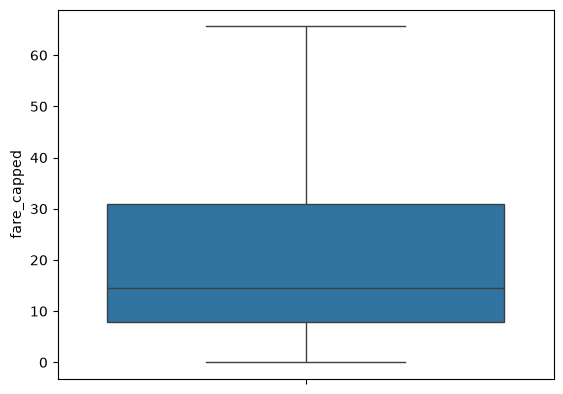

In [70]:
sns.boxplot(df["fare_capped"])